# Notebook 03 — specparam fitting: reconstructed sources (Mantini 2018)

Fits aperiodic parameters on HD-EEG reconstructed source data.
19 subjects × 38 ROIs × 2 hemispheres = 1444 source signals.

**Strategy**: Compute Welch PSD per source signal, then fit specparam on all 1444 spectra.  
Regional aggregation (across subjects) happens in notebook 04.

**Output**: `data/interim/specparam_sources_results.csv`

In [6]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import h5py
from scipy.signal import welch
import matplotlib.pyplot as plt
from specparam import SpectralGroupModel

from pesco.spectral import inspect_fit_quality, inspect_fits, specparam2pandas,  inspect_q_extremes


PROJECT_ROOT = Path("../../").resolve()
#sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR      = PROJECT_ROOT / "data"
SOURCES_DIR   = DATA_DIR / "Mantini2018"
REGION_INFO   = SOURCES_DIR / "RegionInformation.csv"
INTERIM_DIR   = DATA_DIR / "interim"
INTERIM_DIR.mkdir(exist_ok=True)

# ── specparam settings (same as iEEG notebook for comparability) ───────────
FREQ_RANGE        = (2.0, 40.0)
APERIODIC_MODE    = "fixed"
PEAK_WIDTH_LIMITS = [1.0, 12.0]
MAX_N_PEAKS       = 6
MIN_PEAK_HEIGHT   = 0.05
PEAK_THRESHOLD    = 2.0
R2_THRESHOLD      = 0.80

FS        = 200.0   # Hz
N_ROIS    = 38
N_HEMIS   = 2       # R and L
N_CHANS_PER_SUBJ = N_ROIS * N_HEMIS  # 76

## 1. Load source data

Each subject folder contains `roi_data.mat` (HDF5 / MATLAB v7.3).  
Array shape inside: `brain_roi` = (n_samples, 76) — 38 ROIs × 2 hemispheres.  
Channel naming convention: `dataset{subj:02d}_{roi:02d}{hemi}` where hemi ∈ {R, L}.

In [15]:
def load_subject(folder: Path):
    """Load one subject's roi_data.mat and return (data array, channel names).
    data shape: (n_samples, 76)
    """
    mat_file = folder / "roi_data.mat"
    with h5py.File(mat_file, "r") as f:
        dat = np.array(f["brain_roi"])  # shape may be (76, n_samples) or (n_samples, 76)
    # Ensure shape is (n_samples, n_channels)
    if dat.shape[0] == N_CHANS_PER_SUBJ:
        dat = dat.T
    subj_num = int(folder.name[7:])  # 'dataset1' → 1
    names = [
        f"dataset{subj_num:02d}_{roi:02d}{hemi}"
        for roi in range(1, N_ROIS + 1)
        for hemi in ("R", "L")
    ]
    return dat, names


all_psds   = []
all_names  = []
freqs_out  = None

subject_folders = sorted(
    [p for p in SOURCES_DIR.iterdir() if p.is_dir() and p.name.startswith("dataset")]
)
print(f"Found {len(subject_folders)} subject folders")

for folder in subject_folders:
    data_subj, names = load_subject(folder)
    n_samples = data_subj.shape[0]

    nperseg  = int(2 * FS)
    noverlap = int(FS)
    freqs, psds_subj = welch(
        data_subj.T, fs=FS, nperseg=nperseg, noverlap=noverlap,
        detrend="constant", scaling="density"
    )  # psds_subj shape: (76, n_freqs)

    all_psds.append(psds_subj)
    all_names.extend(names)
    if freqs_out is None:
        freqs_out = freqs
    print(f"  {folder.name}: {data_subj.shape}  →  PSD {psds_subj.shape}", end="\r")

all_psds = np.vstack(all_psds)   # (n_subjects * 76, n_freqs)
print(f"\nAll PSDs: {all_psds.shape}  |  Channels: {len(all_names)}")

Found 19 subject folders
  dataset9: (60304, 76)  →  PSD (76, 201))
All PSDs: (1444, 201)  |  Channels: 1444


## 2. Sanity check: median spectra

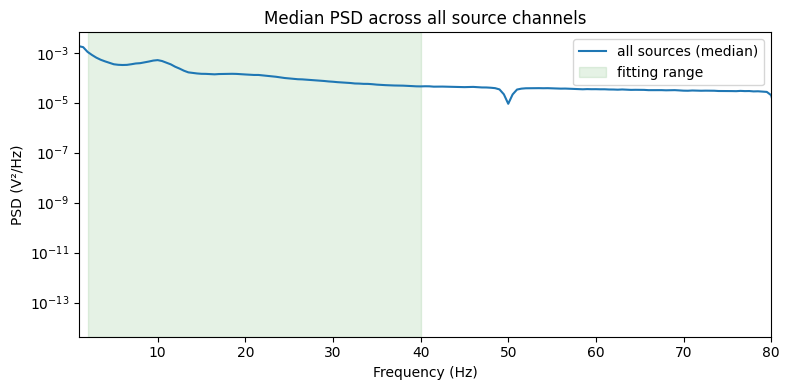

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(freqs_out, np.median(all_psds, axis=0), label="all sources (median)")
ax.set_xlim(1, 80)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (V²/Hz)")
ax.set_title("Median PSD across all source channels")
ax.axvspan(FREQ_RANGE[0], FREQ_RANGE[1], alpha=0.1, color="green", label="fitting range")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Specparam helper

## 4. Fit SpectralGroupModel

In [4]:
freq_mask = (freqs_out >= FREQ_RANGE[0]) & (freqs_out <= FREQ_RANGE[1])
freqs_fit = freqs_out[freq_mask]
psds_fit  = all_psds[:, freq_mask]

fg = SpectralGroupModel(
    peak_width_limits = PEAK_WIDTH_LIMITS,
    max_n_peaks       = MAX_N_PEAKS,
    min_peak_height   = MIN_PEAK_HEIGHT,
    peak_threshold    = PEAK_THRESHOLD,
    aperiodic_mode    = APERIODIC_MODE,
)

print(f"Fitting {psds_fit.shape[0]} spectra …")
fg.fit(freqs_fit, psds_fit, n_jobs=1)
print("Done.")

NameError: name 'freqs_out' is not defined

                                                                                                  
                           GROUP SPECTRAL MODEL RESULTS (1444 spectra)                            
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 0.50 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                         offset   - Min:  -4.76, Max:  -1.15, Mean: -2.74                         
                         exponent - Min:  -0.63, Max:   1.67, Mean:  1.00                         
                                                                                                  
          

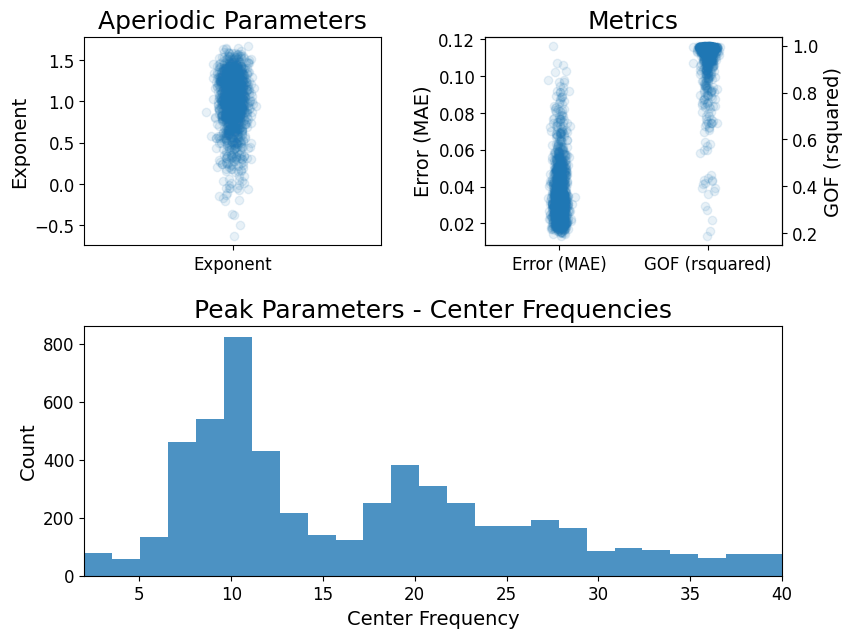

In [19]:
fg.print_results()
fg.plot(n_cols=4, plot_peaks="shade", plot_aperiodic=False)


## 5. QC

In [5]:
results_df = specparam2pandas(fg, add_q=True)
display(results_df )

ch_df, summary_df, fig, axes = inspect_fit_quality(
    results_df, r2_threshold=R2_THRESHOLD, bins=40, show=True
)


NameError: name 'fg' is not defined

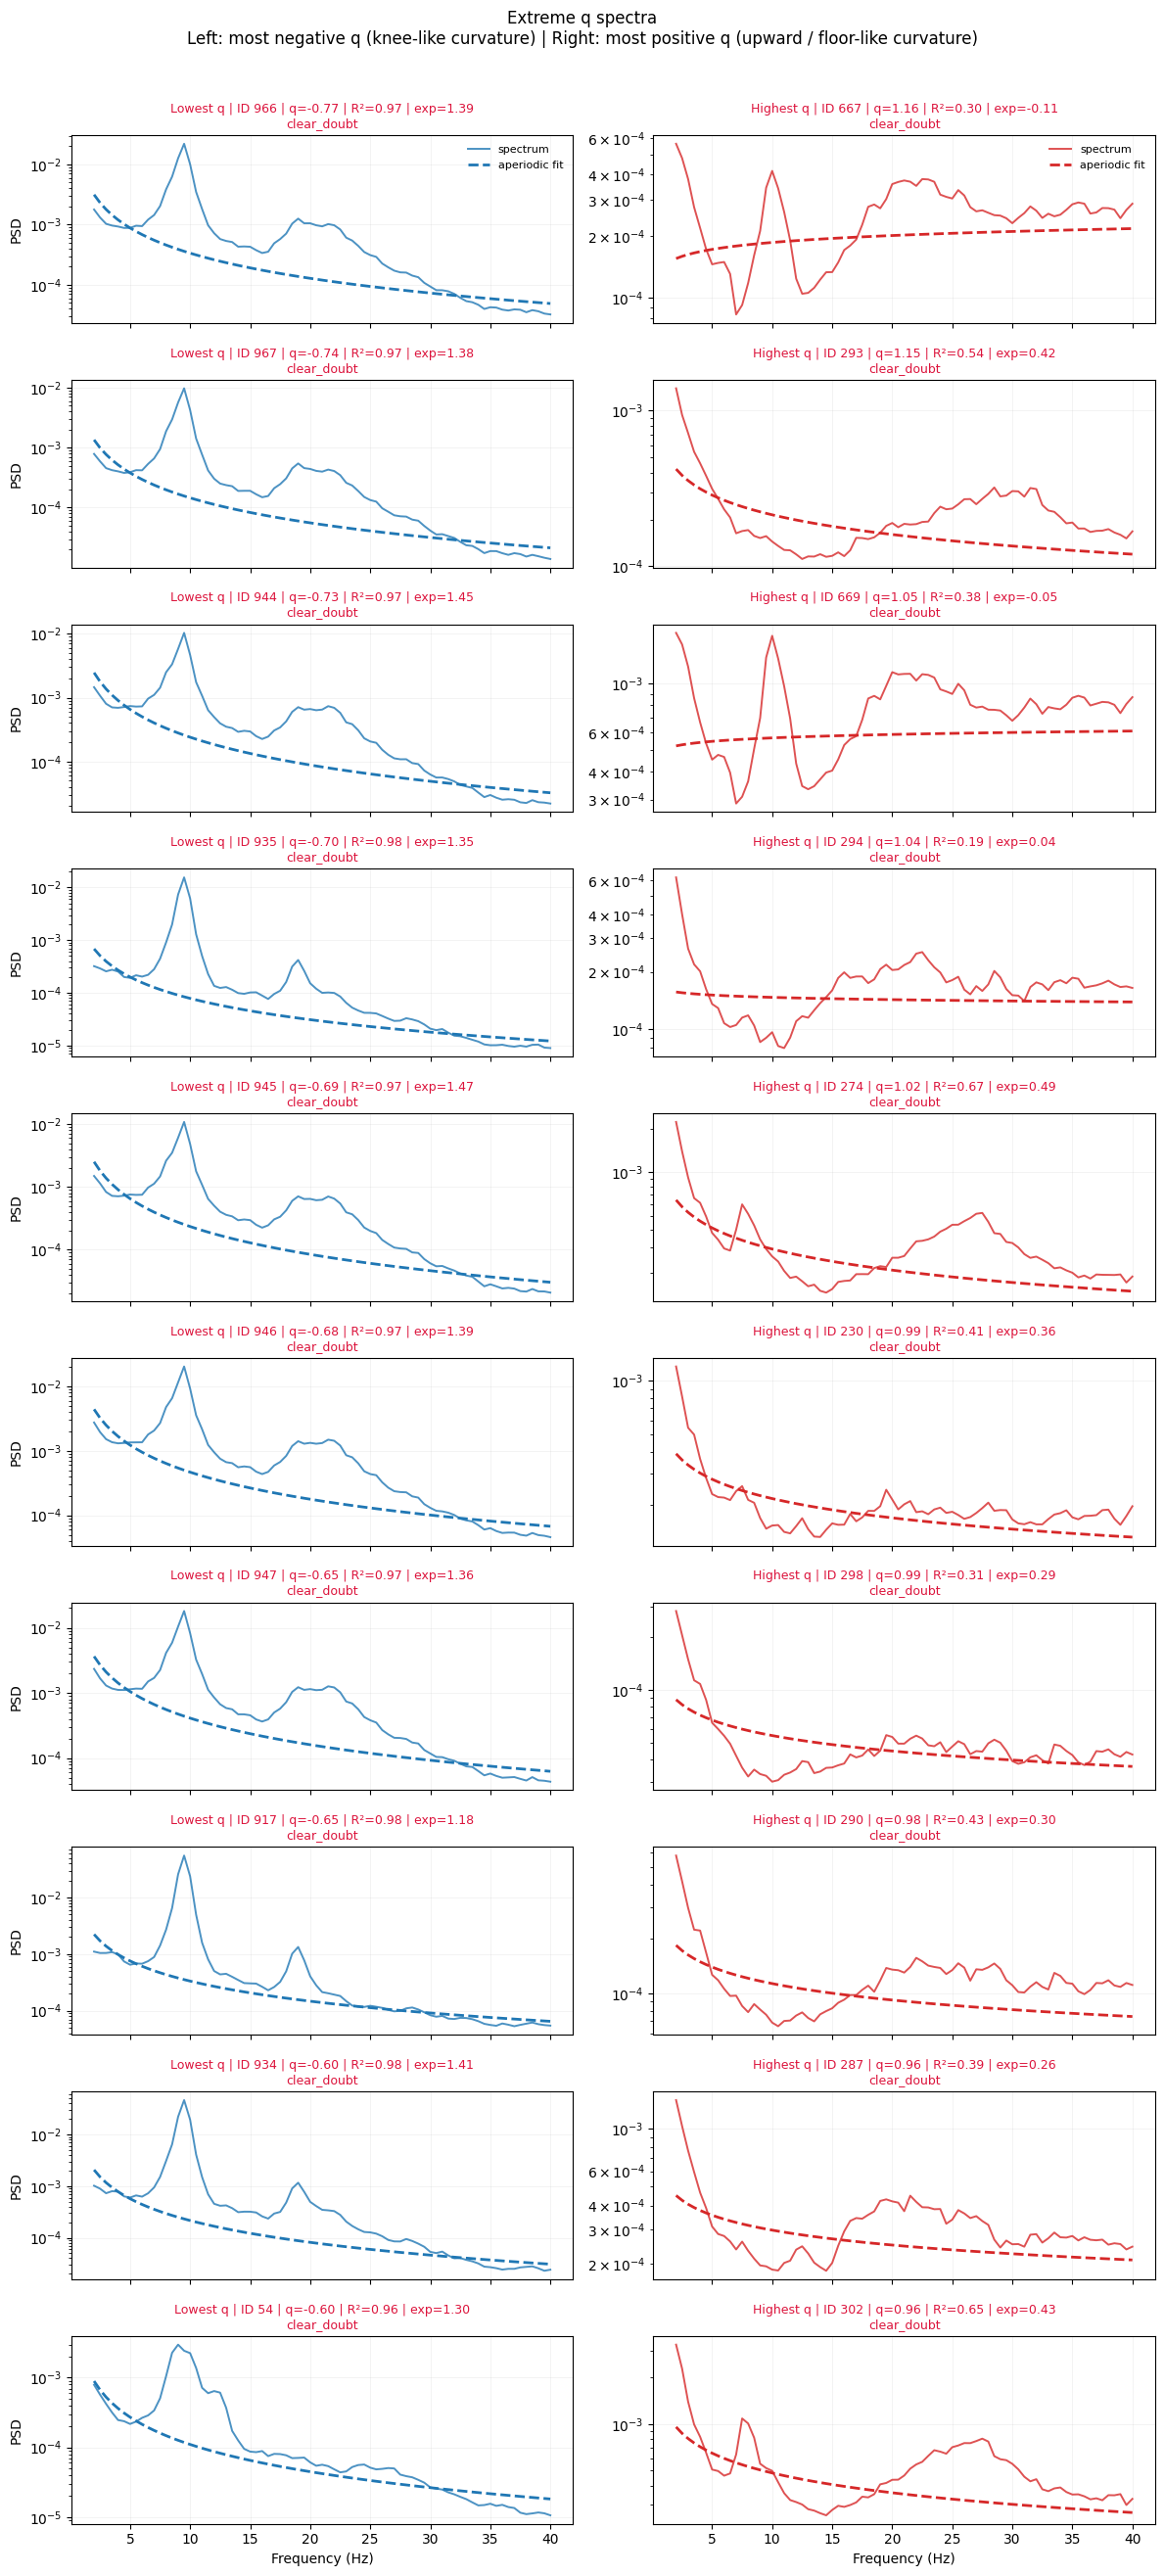

In [29]:
ow_df, high_df, fig, axes = inspect_q_extremes(
    results_df,
    fg,
    psds_fit,
    freqs_fit,
    n_extremes=10,
    show=True,
)

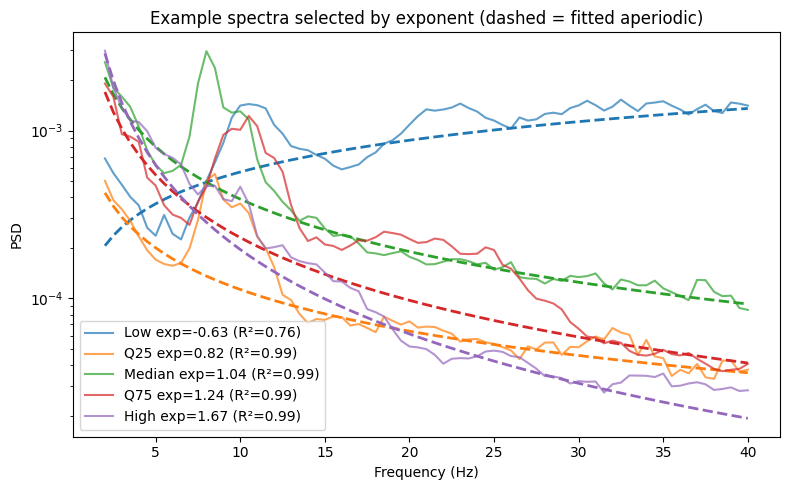

In [9]:
figure, ax = inspect_fits(fg, psds_fit, freqs_fit)

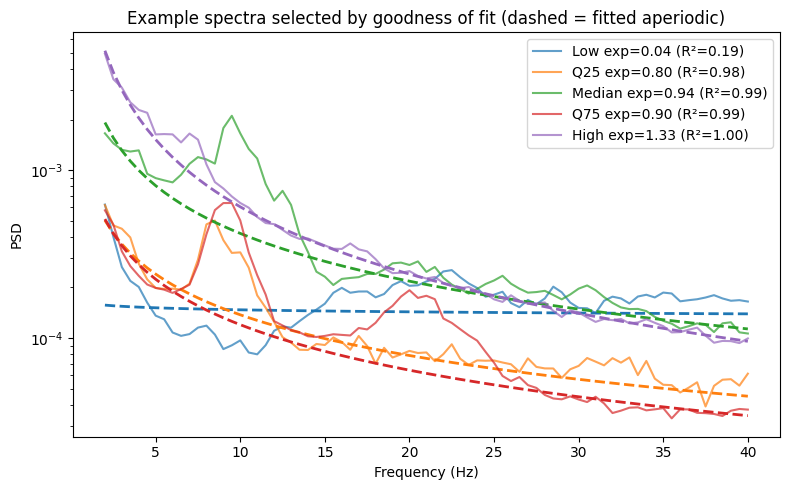

In [10]:
figure, ax = inspect_fits(fg, psds_fit, freqs_fit, select_by="gof")

## 6. Attach region metadata

Parse subject number, ROI number, and hemisphere from the channel name convention  
`dataset{subj:02d}_{roi:02d}{hemi}` (e.g. `dataset01_03R` → subj=1, roi=3, hemi=R).

In [11]:
# Parse channel names
import re

parsed = []
for name in all_names:
    m = re.match(r"dataset(\d+)_(\d+)([RL])", name)
    if m:
        parsed.append({
            "ch_name":    name,
            "subject":    int(m.group(1)),
            "roi_number": int(m.group(2)),
            "hemisphere": m.group(3),
        })
    else:
        parsed.append({"ch_name": name, "subject": np.nan,
                       "roi_number": np.nan, "hemisphere": np.nan})

ch_meta = pd.DataFrame(parsed)
ch_meta["ID"] = range(len(ch_meta))

# Load region info (38 regions; each appears twice for R and L)
region_info = pd.read_csv(REGION_INFO)
region_info.columns = region_info.columns.str.strip()
for col in region_info.select_dtypes("object").columns:
    region_info[col] = region_info[col].str.strip("'")
region_info = region_info.rename(columns={"Region": "roi_number"})

ch_meta = ch_meta.merge(region_info, on="roi_number", how="left")

# Merge onto results
results_full = results_df.merge(ch_meta, on="ID", how="left")
results_full["good_fit"] = results_full["gof_rsquared"] >= R2_THRESHOLD

print(results_full.shape)
results_full.head(3)

(5448, 15)


,ID,offset,exponent,error_mae,gof_rsquared,CF,PW,BW,ch_name,subject,roi_number,hemisphere,Region name,Lobe,good_fit
0,0,-2.371257,1.311792,0.050292,0.991567,9.196263,1.354592,3.550933,dataset01_01R,1,1,R,Superior and middle occipital gyri,Occipital,True
1,0,-2.371257,1.311792,0.050292,0.991567,13.113801,0.489620,2.722040,dataset01_01R,1,1,R,Superior and middle occipital gyri,Occipital,True
2,0,-2.371257,1.311792,0.050292,0.991567,17.914240,0.457999,4.436802,dataset01_01R,1,1,R,Superior and middle occipital gyri,Occipital,True


## 7. Save results

In [13]:
out_path = INTERIM_DIR / "specparam_sources_results.csv"
results_full.to_csv(out_path, index=False)
print(f"Saved {len(results_full)} rows → {out_path}")

ch_summary = results_full.drop_duplicates(subset="ID").drop(columns=["CF", "PW", "BW"], errors="ignore")
ch_summary.to_csv(INTERIM_DIR / "specparam_sources_ch_summary.csv", index=False)
print(f"Saved channel summary → {INTERIM_DIR / 'specparam_sources_ch_summary.csv'}")

if "Lobe" in ch_summary.columns:
    print("\nGood fits by lobe:")
    print(ch_summary[ch_summary["good_fit"]].groupby("Lobe")["exponent"].agg(["count", "median"]).round(3))

Saved 5448 rows → /Users/daniel/PhD/spectral-comparison/data/interim/specparam_sources_results.csv
Saved channel summary → /Users/daniel/PhD/spectral-comparison/data/interim/specparam_sources_ch_summary.csv

Good fits by lobe:
           count  median
Lobe                    
Frontal      544   1.058
Insula        73   1.121
Occipital    179   0.959
Parietal     264   1.086
Temporal     319   1.064


# knee comparison

In [30]:
from specparam import SpectralGroupModel
from pesco.spectral import specparam2pandas
import matplotlib.pyplot as plt
import numpy as np


In [32]:
fixed_df = specparam2pandas(fg, add_q=True, peak_rm=True)
fixed_ch = fixed_df.drop_duplicates("ID").copy()

# Option 1: threshold-based
knee_ids = fixed_ch.loc[
    (fixed_ch["q"] < -0.50) & (fixed_ch["gof_rsquared"] >= R2_THRESHOLD),
    "ID"
].to_numpy()

# Option 2: just take the 10 most negative q values
# knee_ids = fixed_ch.nsmallest(10, "q")["ID"].to_numpy()

print("Candidates:", knee_ids)


Candidates: [  54  479  511  917  932  933  934  935  944  945  946  947  962  964
  966  967 1270]


In [33]:
psds_knee = psds_fit[knee_ids]

fg_knee = SpectralGroupModel(
    peak_width_limits=PEAK_WIDTH_LIMITS,
    max_n_peaks=MAX_N_PEAKS,
    min_peak_height=MIN_PEAK_HEIGHT,
    peak_threshold=PEAK_THRESHOLD,
    aperiodic_mode="knee",
)

fg_knee.fit(freqs_fit, psds_knee, n_jobs=1)

knee_df = specparam2pandas(fg_knee, add_q=True, peak_rm=True)
knee_ch = knee_df.drop_duplicates("ID").copy()

# map subset IDs back to original IDs
knee_ch = knee_ch.rename(columns={"ID": "subset_ID"})
knee_ch["ID"] = knee_ids


Fitting model across 17 power spectra.


In [34]:
fixed_cmp = fixed_ch[
    ["ID", "offset", "exponent", "error_mae", "gof_rsquared", "q", "q_abs", "q_status"]
].copy()
fixed_cmp = fixed_cmp[fixed_cmp["ID"].isin(knee_ids)].add_prefix("fixed_")
fixed_cmp = fixed_cmp.rename(columns={"fixed_ID": "ID"})

knee_cmp = knee_ch[
    ["ID", "offset", "knee", "exponent", "error_mae", "gof_rsquared", "q", "q_abs", "q_status"]
].copy().add_prefix("knee_")
knee_cmp = knee_cmp.rename(columns={"knee_ID": "ID"})

compare = fixed_cmp.merge(knee_cmp, on="ID", how="inner")

compare["delta_r2"] = compare["knee_gof_rsquared"] - compare["fixed_gof_rsquared"]
compare["delta_mae"] = compare["fixed_error_mae"] - compare["knee_error_mae"]
compare["delta_q_abs"] = compare["fixed_q_abs"] - compare["knee_q_abs"]

compare = compare.sort_values(["delta_q_abs", "delta_r2"], ascending=False)
compare


,ID,fixed_offset,fixed_exponent,fixed_error_mae,fixed_gof_rsquared,fixed_q,fixed_q_abs,fixed_q_status,knee_offset,knee_knee,knee_exponent,knee_error_mae,knee_gof_rsquared,knee_q,knee_q_abs,knee_q_status,delta_r2,delta_mae,delta_q_abs
7,935,-2.761493,1.345333,0.086612,0.978722,-0.695799,0.695799,clear_doubt,0.034950,4358.985220,3.192732,0.038594,0.995720,0.076713,0.076713,adequate,0.016998,0.048019,0.619086
3,917,-2.295174,1.181483,0.080940,0.975680,-0.645400,0.645400,clear_doubt,-0.364262,444.364558,2.486953,0.035840,0.995387,0.047281,0.047281,adequate,0.019707,0.045100,0.598119
14,966,-2.083943,1.390169,0.097732,0.971425,-0.772655,0.772655,clear_doubt,1.330278,21880.633728,3.625624,0.058254,0.987863,0.181478,0.181478,mild_concern,0.016438,0.039478,0.591177
2,511,-1.725149,1.552538,0.083046,0.968131,-0.594450,0.594450,clear_doubt,-0.647880,79.430554,2.295886,0.047918,0.989994,-0.016191,0.016191,adequate,0.021863,0.035128,0.578259
15,967,-2.452324,1.384418,0.096554,0.972100,-0.738718,0.738718,clear_doubt,0.850958,16171.200730,3.547631,0.057177,0.988349,0.166998,0.166998,mild_concern,0.016249,0.039376,0.571721
8,944,-2.172818,1.446924,0.094012,0.971427,-0.727666,0.727666,clear_doubt,0.698446,6386.719857,3.342736,0.047899,0.991396,0.167910,0.167910,mild_concern,0.019968,0.046113,0.559756
5,933,-2.330967,1.332081,0.096895,0.969547,-0.595148,0.595148,clear_doubt,0.183389,2093.481007,3.005665,0.031167,0.996913,0.056446,0.056446,adequate,0.027366,0.065728,0.538702
4,932,-2.049638,1.353435,0.071732,0.984468,-0.587173,0.587173,clear_doubt,0.819157,4883.911301,3.231172,0.059035,0.990563,0.059985,0.059985,adequate,0.006094,0.012697,0.527188
9,945,-2.155259,1.474083,0.091783,0.973448,-0.685642,0.685642,clear_doubt,0.673092,5862.715332,3.324788,0.063919,0.985373,0.167624,0.167624,mild_concern,0.011924,0.027864,0.518017
6,934,-2.260670,1.405632,0.078165,0.982320,-0.599969,0.599969,clear_doubt,0.850984,9425.660360,3.448922,0.039234,0.995969,0.087682,0.087682,adequate,0.013649,0.038930,0.512287


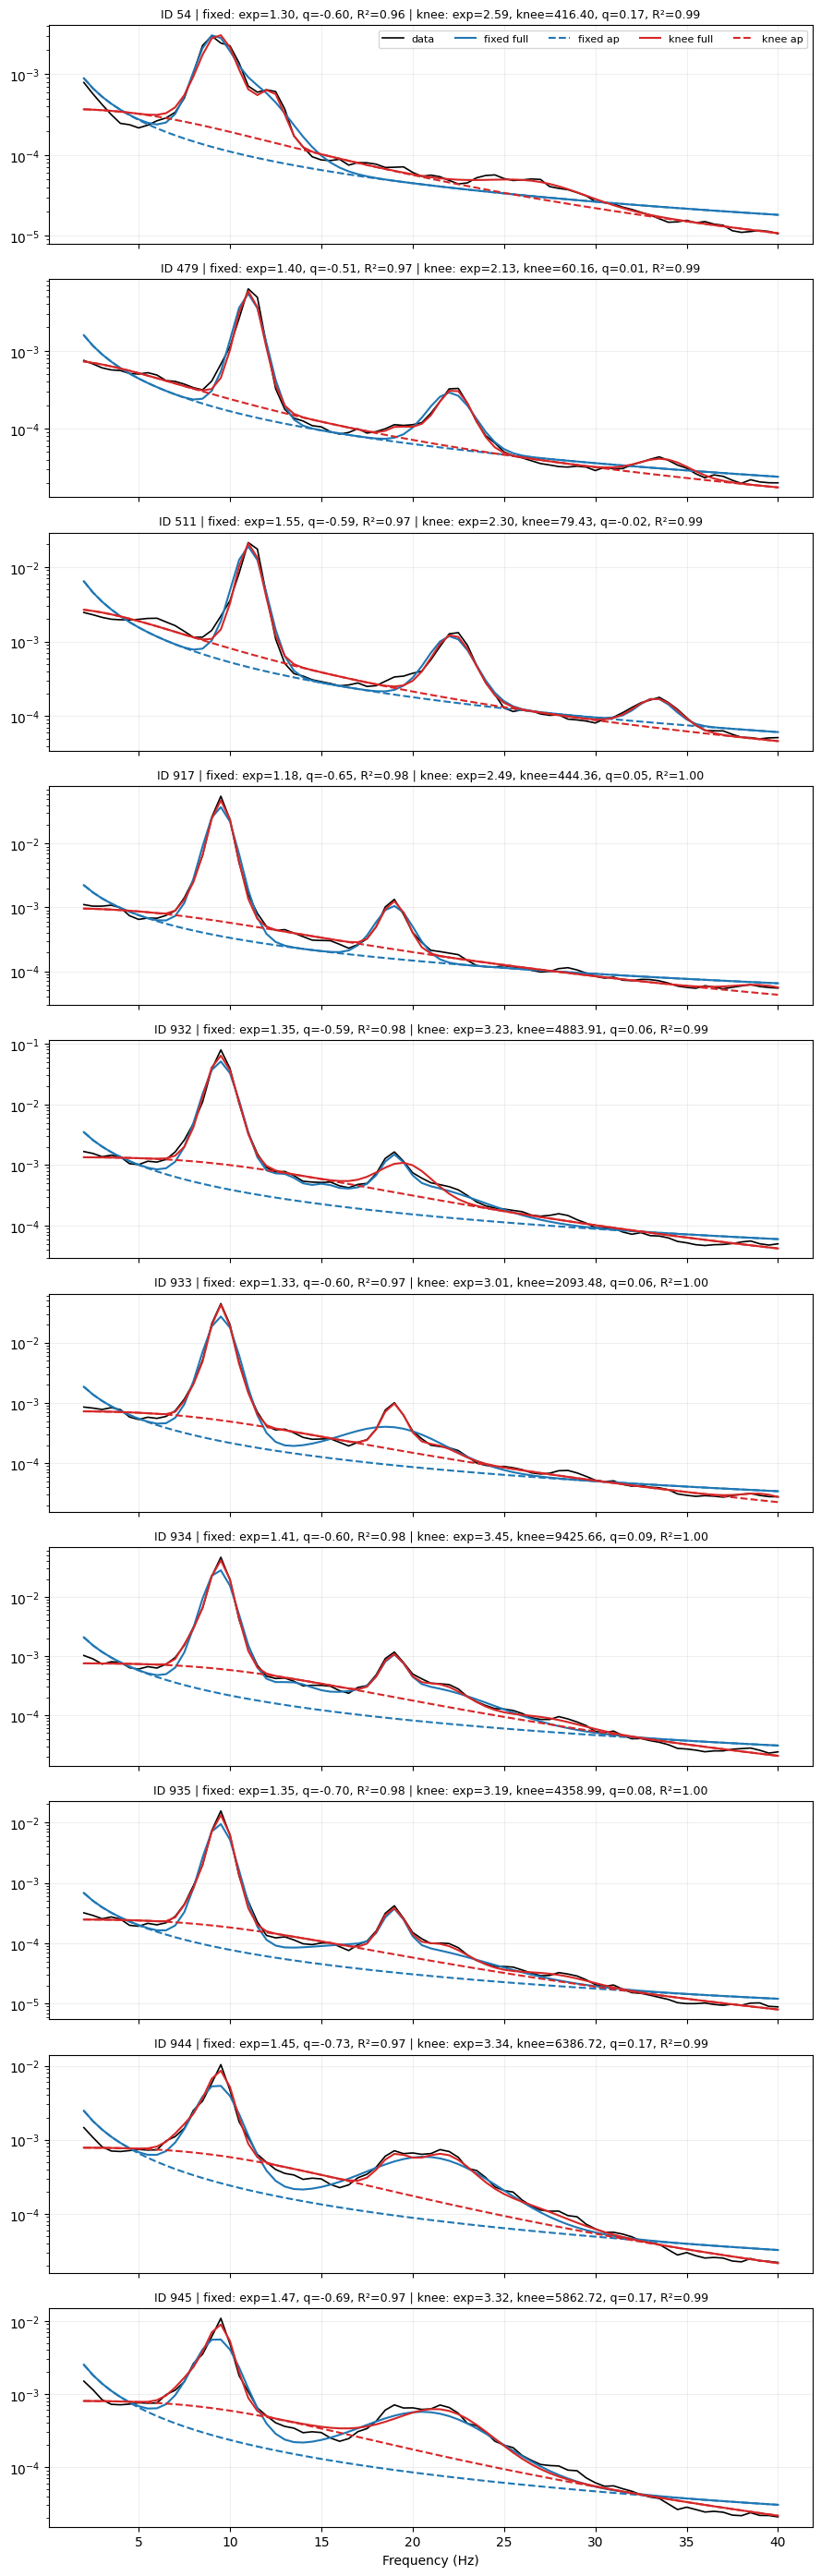

In [36]:
n_plot = min(len(knee_ids), 10)
fig, axes = plt.subplots(n_plot, 1, figsize=(9, 2.8 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

for ax, orig_id, subset_id in zip(axes, knee_ids[:n_plot], range(n_plot)):
    sm_fixed = fg.get_model(orig_id, regenerate=True)
    sm_knee = fg_knee.get_model(subset_id, regenerate=True)

    ax.semilogy(freqs_fit, psds_fit[orig_id], color="k", lw=1.2, label="data")
    ax.semilogy(freqs_fit, 10 ** sm_fixed.results.model.modeled_spectrum, color="C0", label="fixed full")
    ax.semilogy(freqs_fit, 10 ** sm_fixed.results.model._ap_fit, color="C0", ls="--", label="fixed ap")
    ax.semilogy(freqs_fit, 10 ** sm_knee.results.model.modeled_spectrum, color="C3", label="knee full")
    ax.semilogy(freqs_fit, 10 ** sm_knee.results.model._ap_fit, color="C3", ls="--", label="knee ap")

    row = compare.loc[compare["ID"] == orig_id].iloc[0]
    ax.set_title(
        f"ID {orig_id} | "
        f"fixed: exp={row.fixed_exponent:.2f}, q={row.fixed_q:.2f}, R²={row.fixed_gof_rsquared:.2f} | "
        f"knee: exp={row.knee_exponent:.2f}, knee={row.knee_knee:.2f}, q={row.knee_q:.2f}, R²={row.knee_gof_rsquared:.2f}",
        fontsize=9,
    )

    ax.grid(alpha=0.2)

axes[0].legend(ncol=5, fontsize=8)
axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()
